In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Ensure visualizations folder exists
os.makedirs('visualizations', exist_ok=True)

In [3]:
# Load the Housing Price dataset
df_house = pd.read_csv(r'C:\Users\ajasl\OneDrive\Documents\Project\The Developers Arena\Month 2\house_prices.csv')

In [5]:
# Display basic dataset information
print("Dataset Shape:", df_house.shape)
print("\nFirst 5 Rows:")
display(df_house.head())

print("\nMissing Values:")
print(df_house.isnull().sum())

Dataset Shape: (300, 8)

First 5 Rows:


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000



Missing Values:
Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


In [6]:
# Display statistical summary of numerical columns (Area, Bedrooms, Bathrooms, Age, Price)
display(df_house.describe())

,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


C:\Users\ajasl\AppData\Local\Temp\ipykernel_22036\1781440417.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_price.index, y=type_price.values, palette='viridis')


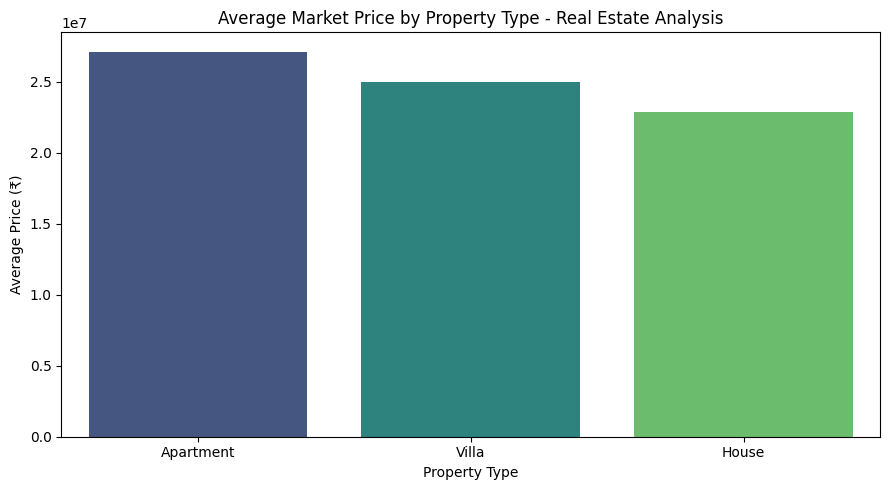

In [7]:
# 1. Average Price by Property Type
plt.figure(figsize=(9, 5))
type_price = df_house.groupby('Property_Type')['Price'].mean().sort_values(ascending=False)

sns.barplot(x=type_price.index, y=type_price.values, palette='viridis')
plt.title('Average Market Price by Property Type - Real Estate Analysis')
plt.xlabel('Property Type')
plt.ylabel('Average Price (₹)')
plt.tight_layout()

In [8]:
# Save visualization
plt.savefig('visualizations/project2_property_type_price.png')
plt.show()

<Figure size 640x480 with 0 Axes>

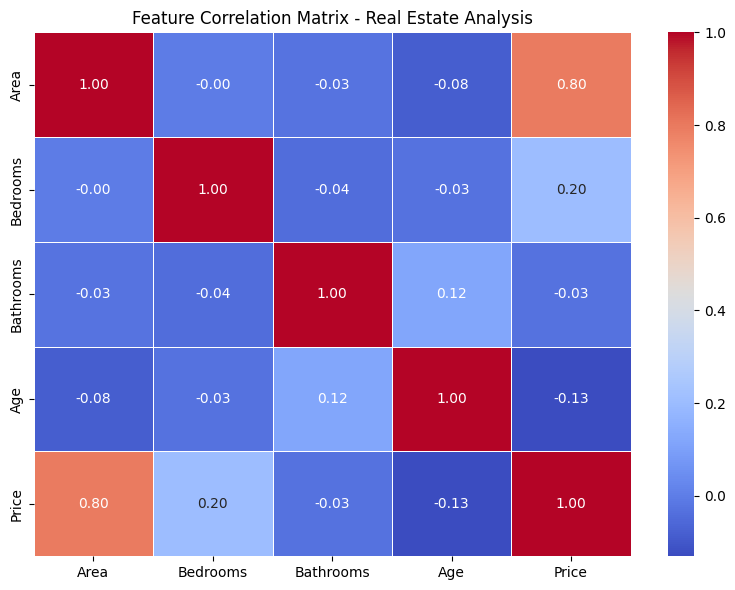

In [9]:
# 2. Correlation Heatmap for Numerical Features
plt.figure(figsize=(8, 6))

# Select only numerical columns to correlate
numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Price']
corr_matrix = df_house[numerical_cols].corr()

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix - Real Estate Analysis')
plt.tight_layout()

# Save visualization
plt.savefig('visualizations/project2_correlation_heatmap.png')
plt.show()

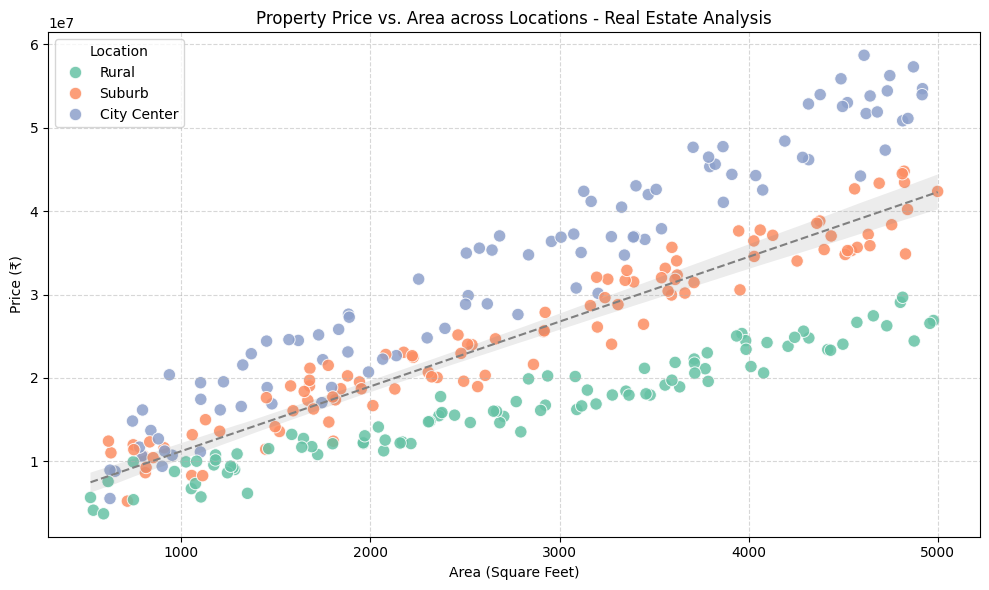

In [10]:
# 3. Price vs. Area Scatter Plot by Location
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_house,
    x='Area',
    y='Price',
    hue='Location',
    palette='Set2',
    s=80,
    alpha=0.85
)

# Overlay a general linear trend line
sns.regplot(
    data=df_house,
    x='Area',
    y='Price',
    scatter=False,
    color='gray',
    line_kws={'linestyle': '--', 'linewidth': 1.5}
)

plt.title('Property Price vs. Area across Locations - Real Estate Analysis')
plt.xlabel('Area (Square Feet)')
plt.ylabel('Price (₹)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save visualization
plt.savefig('visualizations/project2_price_vs_area.png')
plt.show()